# Example segmentations and shape bias

Max-Projection, 7 models. Part 1 shows example crops with GT and predicted contours. Part 2 asks how far each model's
predicted cell shapes are from the ground truth (Area, Eccentricity, Solidity, Compactness).
Scores and per-image predicted shapes come from `results/all_runs.csv` (`validation/consolidate.py`).

In [1]:
import sys
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage.io
from matplotlib.transforms import blended_transform_factory
from skimage.measure import find_contours
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

import figures.render_utils as ru
from figures.utils import holm_adjust, stars
from import_util import DATA_ROOT
from validation.consolidate import DATASETS, load, scores_dir
from validation.multi_model import pred_path_for

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Mesmer", "Dist U-Net", "Cellpose-SAM", "MicroSAM"]
COLORS = {  # seaborn colorblind palette
    "Cellpose": "#0173B2", "InstanSeg": "#DE8F05", "Stardist": "#029E73", "Mesmer": "#D55E00",
    "Dist U-Net": "#CC78BC", "Cellpose-SAM": "#CA9161", "MicroSAM": "#949494",
}
# unitless shape metrics read the same on every dataset, unlike perimeter or axis lengths
SHAPE_METRICS = ["Area", "Eccentricity", "Solidity", "Compactness"]

## Load

In [2]:
scores = load()  # one row per test image of every run, incl. each prediction's mean shape and the GT's
scores = scores[(scores["Modality"] == "MaxProj") & (scores["Arm"] == "selected") & scores["Model"].isin(MODEL_ORDER)]
assert scores.groupby("Model")["ID"].apply(frozenset).nunique() == 1, "models were scored on different images"
scores.head()

,Model,Dataset,Modality,Arm,Fold,Run,ID,Prec,Rec,F1,...,Area,Perimeter,Solidity,Eccentricity,Rectangularity,Major Axis,Minor Axis,Compactness,Aspect Ratios,# Cells
0,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.772222,0.487719,0.597849,...,486.855556,90.231556,0.909034,0.735266,0.662218,31.987700,19.563412,0.729888,1.713498,180
1,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.543379,0.352071,0.427289,...,399.178082,93.268745,0.871949,0.796131,0.614666,33.625810,16.122672,0.608399,2.149910,219
2,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.571429,0.417910,0.482759,...,384.995918,87.888310,0.877116,0.774406,0.626406,30.845971,16.582867,0.626017,1.937359,245
3,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.659218,0.556604,0.603581,...,524.938547,96.730130,0.896752,0.745845,0.636757,33.841469,20.139882,0.685191,1.816212,179
4,Dist U-Net,Vectra,MaxProj,selected,0,DIST_Vectra_MaxProj_filtered,/home/benjaminba/Documents/Project_data/Multip...,0.606557,0.388451,0.473600,...,458.012295,92.656685,0.884473,0.746153,0.644012,32.804142,18.282298,0.665981,1.795117,244


## Example segmentations

Curated crops (`render_utils.GALLERY_EXAMPLES`): Max-Proj image with the ground truth (left) and each model's prediction
as white contours. One PDF per crop.

In [3]:
def overlay_contours(ax, label_img, color="white", linewidth=1.2):
    for lbl in np.unique(label_img):
        if lbl == 0:
            continue
        for contour in find_contours(label_img == lbl, level=0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=linewidth, color=color)


runs = scores.set_index(["Model", "Dataset", "ID"])[["Run", "Fold"]]  # which run/fold scored each test image

for dataset in DATASETS:
    for i, ex in enumerate(ru.load_gallery_examples(dataset)):
        y1, y2, x1, x2 = ex["crop"]
        fig, axs = plt.subplots(1, 1 + len(MODEL_ORDER), figsize=(3 * (1 + len(MODEL_ORDER)), 3.4))

        axs[0].imshow(ex["max_proj"])
        overlay_contours(axs[0], ex["label"])
        axs[0].set_title("Ground truth", fontsize=11)

        for ax, model in zip(axs[1:], MODEL_ORDER):
            run = runs.loc[(model, dataset, Path(ex["label_path"]).relative_to(DATA_ROOT).as_posix())]
            pred = skimage.io.imread(pred_path_for(str(scores_dir(model, dataset)), run["Run"], run["Fold"], ex["label_path"]))
            ax.imshow(ex["max_proj"])
            overlay_contours(ax, pred[y1:y2, x1:x2])
            ax.set_title(model, fontsize=11)

        for ax in axs:
            ax.axis("off")
        fig.suptitle(f"{dataset} -- example segmentation (Max-Proj) [{i}]", fontsize=15, y=1.05)
        fig.tight_layout()
        fig.savefig(EXPORT_DIR / f"Example_Segmentation_{dataset}_{i}.pdf", bbox_inches="tight")
        plt.close(fig)

/home/benjaminba/Documents/Projects/MIP-for-multiplexed-segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shape bias against the ground truth

Per image: mean predicted shape minus mean GT shape (`diff`), for each model and metric.

In [4]:
pred_shapes = scores[["Model", "Dataset", "ID"] + SHAPE_METRICS]
gt_shapes = (scores.drop_duplicates("ID")[["ID"] + [f"GT_{m}" for m in SHAPE_METRICS]]
             .rename(columns={f"GT_{m}": m for m in SHAPE_METRICS}))  # shape of the GT label image

merged = pred_shapes.merge(gt_shapes, on="ID", suffixes=("_pred", "_gt"))
diff_long = pd.concat([
    merged[["Model", "Dataset", "ID"]].assign(metric=m, diff=merged[f"{m}_pred"] - merged[f"{m}_gt"])
    for m in SHAPE_METRICS
], ignore_index=True)
diff_long.head()

,Model,Dataset,ID,metric,diff
0,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,Area,75.939766
1,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,Area,83.837846
2,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,Area,42.195918
3,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,Area,9.943264
4,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,Area,130.085786


## Statistics: predicted vs. GT, per model

Per model and metric: Type II ANOVA `Value ~ Source + Dataset` on the predicted and GT per-image values
(Source = Predicted / GT), Holm-corrected across the 7 models. The ANOVA treats the predicted and GT value of an
image as independent observations. `mean_diff` and `median_diff` are the paired per-image differences
(predicted minus GT). Stars appear on the first figure below.

In [5]:
sig = {}  # metric -> table with one row per model
for metric in SHAPE_METRICS:
    rows = []
    for model in MODEL_ORDER:
        m = merged[merged["Model"] == model]
        per_image_diff = (m[f"{metric}_pred"] - m[f"{metric}_gt"]).dropna()

        long = pd.concat([
            pd.DataFrame({"Value": m[f"{metric}_pred"], "Dataset": m["Dataset"], "Source": "Predicted"}),
            pd.DataFrame({"Value": m[f"{metric}_gt"], "Dataset": m["Dataset"], "Source": "GT"}),
        ], ignore_index=True)
        anova = anova_lm(ols("Value ~ C(Source) + C(Dataset)", data=long).fit(), typ=2)
        rows.append({
            "Model": model, "metric": metric, "n": len(per_image_diff),
            "mean_diff": per_image_diff.mean(), "median_diff": per_image_diff.median(),
            "F": anova.loc["C(Source)", "F"], "p_raw": anova.loc["C(Source)", "PR(>F)"],
        })
    sig[metric] = pd.DataFrame(rows)
    sig[metric]["p_holm"] = holm_adjust(sig[metric]["p_raw"])
    sig[metric]["stars"] = sig[metric]["p_holm"].apply(stars)

    print(f"=== {metric}: ANOVA per model (adjusting for imaging technology), Holm-corrected ===")
    display(sig[metric])

=== Area: ANOVA per model (adjusting for imaging technology), Holm-corrected ===


,Model,metric,n,mean_diff,median_diff,F,p_raw,p_holm,stars
0,Cellpose,Area,250,-107.269008,4.278316,2.891816,8.965862e-02,2.317831e-01,ns
1,InstanSeg,Area,250,-111.603462,-10.956971,3.134633,7.726103e-02,2.317831e-01,ns
2,Stardist,Area,250,-240.266987,-68.220069,14.488017,1.587346e-04,9.524074e-04,***
3,Mesmer,Area,250,-83.902588,7.135235,1.351887,2.455088e-01,2.455088e-01,ns
4,Dist U-Net,Area,250,-173.573589,28.548649,7.986568,4.903105e-03,2.272618e-02,*
5,Cellpose-SAM,Area,250,-187.847509,-19.618558,8.126150,4.545237e-03,2.272618e-02,*
6,MicroSAM,Area,250,-488.696248,-21.745340,61.195689,3.146445e-14,2.202511e-13,***


=== Eccentricity: ANOVA per model (adjusting for imaging technology), Holm-corrected ===


,Model,metric,n,mean_diff,median_diff,F,p_raw,p_holm,stars
0,Cellpose,Eccentricity,250,-0.017127,-0.016198,40.855930,3.790535e-10,3.790535e-10,***
1,InstanSeg,Eccentricity,250,-0.027386,-0.027480,109.045115,3.329549e-23,1.331819e-22,***
2,Stardist,Eccentricity,250,-0.050540,-0.049783,355.783677,3.365694e-60,2.355986e-59,***
3,Mesmer,Eccentricity,250,-0.046014,-0.049153,347.652049,3.649821e-59,2.189893e-58,***
4,Dist U-Net,Eccentricity,250,-0.023387,-0.019456,81.800167,3.423127e-18,6.846254e-18,***
5,Cellpose-SAM,Eccentricity,250,-0.034326,-0.029457,102.862174,4.350135e-22,1.305040e-21,***
6,MicroSAM,Eccentricity,250,-0.044235,-0.045265,255.538072,1.113620e-46,5.568098e-46,***


=== Solidity: ANOVA per model (adjusting for imaging technology), Holm-corrected ===


,Model,metric,n,mean_diff,median_diff,F,p_raw,p_holm,stars
0,Cellpose,Solidity,250,0.004154,0.007184,8.029308,4.790566e-03,4.790566e-03,**
1,InstanSeg,Solidity,250,0.020293,0.021466,334.736224,1.688022e-57,6.752089e-57,***
2,Stardist,Solidity,250,0.025279,0.026885,577.783555,3.557020e-85,2.134212e-84,***
3,Mesmer,Solidity,250,0.009774,0.012182,64.412874,7.384604e-15,2.215381e-14,***
4,Dist U-Net,Solidity,250,-0.004575,-0.003564,12.729710,3.949111e-04,7.898222e-04,***
5,Cellpose-SAM,Solidity,250,0.029524,0.027304,663.461402,1.900641e-93,1.330449e-92,***
6,MicroSAM,Solidity,250,0.021666,0.021880,379.860452,3.306599e-63,1.653300e-62,***


=== Compactness: ANOVA per model (adjusting for imaging technology), Holm-corrected ===


,Model,metric,n,mean_diff,median_diff,F,p_raw,p_holm,stars
0,Cellpose,Compactness,250,0.009331,0.015977,5.826134,1.615181e-02,1.615181e-02,*
1,InstanSeg,Compactness,250,0.057381,0.063372,267.673410,2.070930e-48,1.035465e-47,***
2,Stardist,Compactness,250,0.103064,0.106676,981.316553,1.532946e-119,1.073062e-118,***
3,Mesmer,Compactness,250,0.025751,0.034205,44.399612,7.150553e-11,2.145166e-10,***
4,Dist U-Net,Compactness,250,-0.024909,-0.016282,38.164740,1.358080e-09,2.716160e-09,***
5,Cellpose-SAM,Compactness,250,0.061879,0.058906,238.067882,3.876508e-44,1.550603e-43,***
6,MicroSAM,Compactness,250,0.065776,0.068197,384.492482,8.918805e-64,5.351283e-63,***


## Violins: shape bias, all datasets pooled

One dot per image, black bar = median, stars from the table above. The y-axes are fixed so the violins are comparable;
values outside them are clipped.

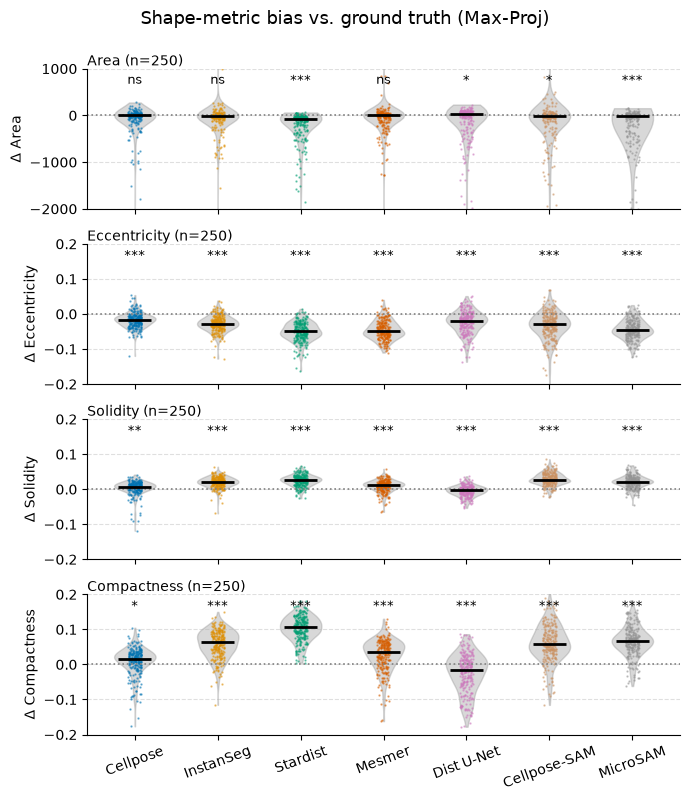

In [6]:
def plot_violin(ax, data, metric, sig_table=None):
    vals = [data.loc[(data["Model"] == m) & (data["metric"] == metric), "diff"].values for m in MODEL_ORDER]

    parts = ax.violinplot(vals, showmedians=False, showextrema=False)
    for body in parts["bodies"]:
        body.set(facecolor="gray", alpha=0.3, edgecolor="gray")

    rng = np.random.default_rng(0)
    for i, (model, v) in enumerate(zip(MODEL_ORDER, vals), start=1):
        ax.scatter(i + rng.uniform(-0.08, 0.08, size=len(v)), v, color=COLORS[model], alpha=0.5, s=0.5, zorder=2)
        ax.hlines(np.median(v), i - 0.2, i + 0.2, color="black", linewidth=2, zorder=3)

    ax.axhline(0, color="gray", linestyle=":", linewidth=1.2)
    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels(MODEL_ORDER, rotation=20)
    ax.set_ylabel(f"Δ {metric}")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    if sig_table is not None:  # stars along the top edge
        trans = blended_transform_factory(ax.transData, ax.transAxes)
        for i, s in enumerate(sig_table.set_index("Model").loc[MODEL_ORDER, "stars"], start=1):
            ax.text(i, 0.96, s, transform=trans, ha="center", va="top", fontsize=9)


fig, axs = plt.subplots(len(SHAPE_METRICS), 1, figsize=(7, 2.0 * len(SHAPE_METRICS)), sharex=True)
for ax, metric in zip(axs, SHAPE_METRICS):
    plot_violin(ax, diff_long, metric, sig[metric])
    ax.set_ylim(-2000, 1000) if metric == "Area" else ax.set_ylim(-0.2, 0.2)
    n = diff_long[diff_long["metric"] == metric].groupby("Model").size().iloc[0]
    ax.set_title(f"{metric} (n={n})", fontsize=10, loc="left", pad=2)
for ax in axs[:-1]:
    ax.tick_params(labelbottom=False)

fig.suptitle("Shape-metric bias vs. ground truth (Max-Proj)", fontsize=13, y=0.995)
fig.tight_layout()
fig.subplots_adjust(hspace=0.25)
fig.savefig(EXPORT_DIR / "ShapeDiff_All.pdf", bbox_inches="tight")

## Violins: shape bias by dataset

The same bias split by imaging technology, since it is not uniform across datasets. No statistics here.

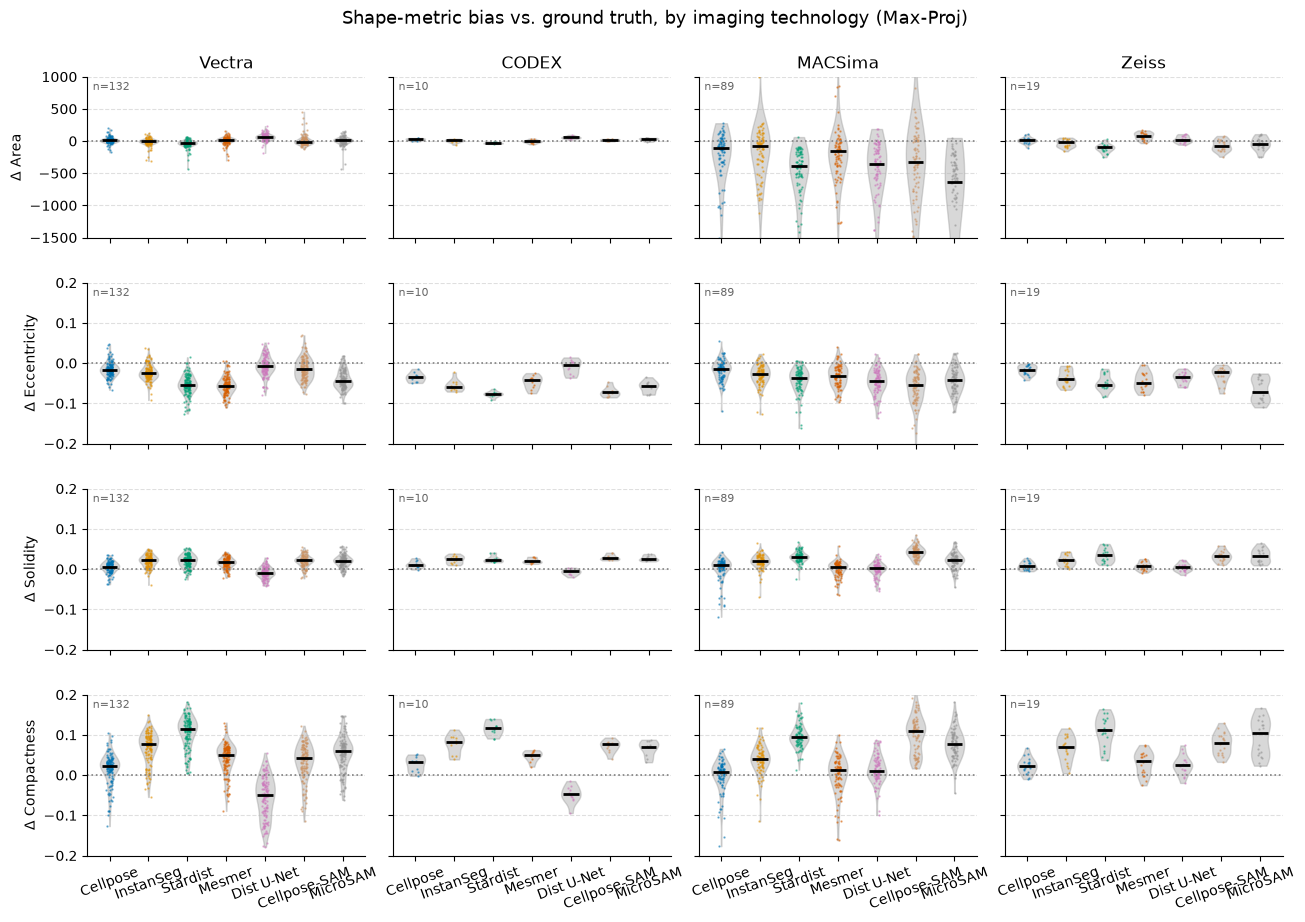

In [7]:
fig, axs = plt.subplots(len(SHAPE_METRICS), len(DATASETS), figsize=(3.3 * len(DATASETS), 2.3 * len(SHAPE_METRICS)),
                        sharex=True, sharey="row")
for r, metric in enumerate(SHAPE_METRICS):
    for c, dataset in enumerate(DATASETS):
        ax = axs[r, c]
        ds_diff = diff_long[diff_long["Dataset"] == dataset]
        plot_violin(ax, ds_diff, metric)
        ax.set_ylim(-1500, 1000) if metric == "Area" else ax.set_ylim(-0.2, 0.2)
        if r == 0:
            ax.set_title(dataset, fontsize=12)
        if c != 0:
            ax.set_ylabel("")
        n = ds_diff[ds_diff["metric"] == metric].groupby("Model").size().iloc[0]
        ax.text(0.02, 0.97, f"n={n}", transform=ax.transAxes, ha="left", va="top", fontsize=8, color="0.4")
for ax in axs[:-1].ravel():
    ax.tick_params(labelbottom=False)

fig.suptitle("Shape-metric bias vs. ground truth, by imaging technology (Max-Proj)", fontsize=13, y=0.997)
fig.tight_layout()
fig.subplots_adjust(hspace=0.28, wspace=0.1)
fig.savefig(EXPORT_DIR / "ShapeDiff_ByDataset.pdf", bbox_inches="tight")